In [1]:
import http
from collections import defaultdict

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text
from itertools import product

In [2]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [3]:
CODES_TO_LANGS = {
    "ar": "Arabic (Modern Standard)",
    "de": "German",
    "en_UK": "English (Received Pronunciation)",
    "en_US": "English (General American)",
    "eo": "Esperanto",
    "es_ES": "Spanish (Spain)",
    "es_MX": "Spanish (Mexico)",
    "fa": "Persian",
    "fi": "Finnish",
    "fr_FR": "French (France)",
    "fr_QC": "French (Québec)",
    "is": "Icelandic",
    "ja": "Japanese",
    "jam": "Jamaican Creole",
    "km": "Khmer",
    "ko": "Korean",
    "ma": "Malay (Malaysian and Indonesian)",
    "nb": "Norwegian Bokmål",
    "nl": "Dutch",
    "or": "Odia",
    "ro": "Romanian",
    "sv": "Swedish",
    "sw": "Swahili",
    "tts": "Isan",
    "vi_C": "Vietnamese (Central)",
    "vi_N": "Vietnamese (Northern)",
    "vi_S": "Vietnamese (Southern)",
    "yue": "Cantonese",
    "zh_hans": "Mandarin (Simplified)",
    "zh_hant": "Mandarin (Traditional)"
}
ISO_CODES = list(CODES_TO_LANGS.keys())

In [4]:
def get_ipa_transcriptions(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict

    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any,
        else an empty list
    """
    return dataset.get(word.lower(), "").split(", ")

In [5]:
def download_ipa_corpus(iso_lang: str) -> str:
    """Get ipa-dict file from Github

    Parameters:
    -----------
    iso_lang:
        Language as iso code

    Results:
    --------
    dict:
        Dictionary with words as keys and phonetic representation
        as values for a given lang code
    """
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

In [6]:
def parse_response(response: str) -> dict:
    """Parse text response from ipa-dict to python dict

    Each row have the format:
    [WORD][TAB]/[IPA]/(, /[IPA]/)?

    Parameters
    ----------
    response: str
        ipa-dict raw text

    Returns
    -------
    dict:
        A dictionary with the word as key and the phonetic
        representations as value
    """
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [7]:
def get_corpora() -> dict:
    """Download corpora from ipa-dict github

    Given a list of iso lang codes download available datasets.

    Returns
    -------
    dict
        Lang codes as keys and dictionary with words-transcriptions
        as values
    """
    return {
        code: parse_response(download_ipa_corpus(code))
         for code in ISO_CODES
        }

In [8]:
CORPORA = get_corpora()

## Fonética

Proponemos aproximar la representación fonética de una palabra tratando de partir la palabra en subpalabras que también se encuentren en el corpus.
Si logramos encontrar una serie de palabras en el corpus cuya concatenación sea la palabra original, podemos aproximar la representación fonética de la palabra como la concatenación de las representaciones de estas.

In [9]:
def match_by_subwords(word:str, dataset):
    """
    Attempts to decompose a target word into a sequence of subwords found in the dataset.
    
    The function iteratively combines keys from the dataset (up to a depth of 6) 
    to see if their concatenation matches the target word or forms a substring of it.
    
    Args:
        word (str): The target string to reconstruct or match.
        dataset (dict/Mapping): A collection where keys represent valid subwords.
        
    Returns:
        list[str]: A list of subword keys that concatenate to form the exact 'word'.
                   Returns an empty list if no exact match is found within 6 iterations.
    """
    parcial_matches = defaultdict(list)
    parcial_matches[1] = [[key] for key in dataset.keys() if word.find(key)>-1]

    for i in range(1,6):
        for x, y in product(parcial_matches[i], parcial_matches[1]):
            parcial = "".join(x+y)
            if word.find(parcial) > -1:
                if parcial == word:
                    return x+y
                parcial_matches[i+1].append(x+y)
    return []

In [10]:
def get_ipa_transcriptions_extended(word: str, dataset: dict) -> list[str]:
    """Search for a word in an IPA phonetics dict
    If not found, it tries to find subwords.
    Given a word this function return the IPA transcriptions

    Parameters:
    -----------
    word: str
        A word to search in the dataset
    dataset: dict
        A dataset for a given language code

    Returns
    -------
    list[str]:
        List with posible transcriptions if any,
        else an empty list
    """
    word = word.lower()
    if word in dataset:
        return dataset.get(word, "").split(", ")

    subwords = match_by_subwords(word, dataset)

    if subwords:
        ipas = [dataset[sub].replace("/","") for sub in subwords]
        return ["/"+"".join(ipas)+"/"]
    return []

In [11]:
WORDS = ["comercializadoras", "aglutinamiento", "desparacitar", "desparacitación"]

In [12]:
for word in WORDS:
    if word in CORPORA["es_MX"]:
        print(f"The word '{word}' is found in the corpus.")
    else:
        print(f"The word '{word}' is NOT found in the corpus.")
    guessed_ipa = get_ipa_transcriptions_extended(word, CORPORA["es_MX"])[0]
    print(f"The guessed IPA for this word is {guessed_ipa}\n")

The word 'comercializadoras' is NOT found in the corpus.
The guessed IPA for this word is /komeɾsjalisadoɾas/

The word 'aglutinamiento' is NOT found in the corpus.
The guessed IPA for this word is /aɣlutinamjento/

The word 'desparacitar' is NOT found in the corpus.
The guessed IPA for this word is /despaɾasitaɾ/

The word 'desparacitación' is NOT found in the corpus.
The guessed IPA for this word is /despaɾasitaˈsjon/



In [13]:
def get_formated_string(code: str, name: str):
    return f"[b]{name}[/b]\n[yellow]{code}"

In [16]:
rprint(
    Panel(Text("Representación fonética de palabras", style="bold", justify="center"))
)
rendable_langs = [
    Panel(get_formated_string(code, lang), expand=True)
    for code, lang in CODES_TO_LANGS.items()
]
rprint(Columns(rendable_langs))

lang = input("lang>> ")
rprint(f"Selected language: {CODES_TO_LANGS[lang]}") if lang else rprint("Adios 👋🏼")
dataset = CORPORA[lang]
query = input(f"  [{lang}]word>> ")

while query:
        results = get_ipa_transcriptions_extended(query, dataset)
        rprint(query, " | ", ", ".join(results))
        query = input(f"  [{lang}]word>> ")


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                       Representación fonética de palabras                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Arabic (Modern Standard)   │ │ German                           │ │ English (Received Pronunciation) │
│ ar                         │ │ de                               │ │ en_UK                            │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ English (General American) │ │ Esperanto                        │ │ Spanish (Spain)                  │
│ en_US                      │ │ eo                               │ │ es_ES                            │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Spanish (Mexico)           │ │ Persian                          │ │ Finnish                          │
│ es_MX                      │ │ fa                               │ │ fi                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ French (France)            │ │ French (Québec)                  │ │ Icelandic                        │
│ fr_FR                      │ │ fr_QC                            │ │ is                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Japanese                   │ │ Jamaican Creole                  │ │ Khmer                            │
│ ja                         │ │ jam                              │ │ km                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Korean                     │ │ Malay (Malaysian and Indonesian) │ │ Norwegian Bokmål                 │
│ ko                         │ │ ma                               │ │ nb                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Dutch                      │ │ Odia                             │ │ Romanian                         │
│ nl                         │ │ or                               │ │ ro                               │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Swedish                    │ │ Swahili                          │ │ Isan                             │
│ sv                         │ │ sw                               │ │ tts                              │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Vietnamese (Central)       │ │ Vietnamese (Northern)            │ │ Vietnamese (Southern)            │
│ vi_C                       │ │ vi_N                             │ │ vi_S                             │
╰────────────────────────────╯ ╰──────────────────────────────────╯ ╰──────────────────────────────────╯
╭────────────────────────────╮ ╭──────────────────────────────────╮ ╭──────────────────────────────────╮
│ Cantonese                  │ │ Mandarin (Simplified)            │ │ Mandarin (Traditional)           │
│ yue     

lang>>  


Adios 👋🏼

KeyError: ''

## Morfología

In [17]:
LANGS = {
    "ces": "Czech",
    "eng": "English",
    "fra": "French",
    "hun": "Hungarian",
    "spa": "Spanish",
    "ita": "Italian",
    "lat": "Latin",
    "rus": "Russian",
}
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}

In [18]:
def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task

    Con base en el idioma y el track obtiene el nombre de los archivos
    para con información reelevante para hacer análisis estadístico.
    Esto es archivos .test y .dev

    Parameters:
    ----------
    lang : str
        Idioma para el cual se generarán los nombres de archivo.
    track : str, optional
        Track del shared task de donde vienen los datos (por defecto es "word").

    Returns:
    -------
    list[str]
        Una lista de nombres de archivo generados para el idioma y la pista especificados.
    """
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

In [19]:
def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde una URL base.

    Parameters:
    ----------
    files : list
        Lista de nombres de archivos (sin extensión) que se descargarán
        y concatenarán.

    Returns:
    -------
    list
        Una lista que contiene los contenidos descargados y concatenados
        de los archivos tsv.
    """
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv")
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

In [20]:
def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame

    Parameters:
    ----------
    corpus_list : list
        Lista de líneas del corpus a convertir en DataFrame.
    lang : str
        Idioma al que pertenecen los datos del corpus.

    Returns:
    -------
    pd.DataFrame
        Un DataFrame de pandas que contiene los datos del corpus procesados.
    """
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            # Caso donde no existe la categoria
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes: list = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda list: len(list))
    return df

In [21]:
dfs = []
for lang in LANGS.keys():
    files = get_track_files(lang)
    raw = get_raw_corpus(files)
    df = raw_corpus_to_dataframe(raw, lang=lang)
    dfs.append(df)

In [22]:
df = pd.concat(dfs)

In [23]:
df['inflection'] = (df['category'].str[0] == '1').astype(int)
df['derivation'] = (df['category'].str[1] == '1').astype(int)
df['compund'] = (df['category'].str[2] == '1').astype(int)

In [24]:
metrics = df.groupby('lang').agg(
    morph_per_word=('morph_count', 'mean'),
    inflection=('inflection', 'sum'),
    derivation=('derivation', 'sum'),
    compound=('compund', 'sum'),
    root=('words','count')
)

metrics['inflection_derivation_ratio'] = metrics['inflection'] / metrics['derivation']

In [25]:
metrics

,morph_per_word,inflection,derivation,compound,root,inflection_derivation_ratio
lang,,,,,,
ces,3.590750,0,0,0,8000,NaN
eng,2.353230,50019,66560,9111,115126,0.751487
fra,2.668640,46413,38977,573,63173,1.190779
hun,3.230282,179358,88266,39529,188074,2.032017
ita,2.682657,78609,49881,205,92304,1.575931
lat,2.489004,0,0,0,176467,NaN
rus,3.851561,141262,111477,1032,156846,1.267185
spa,3.236228,163334,84561,224,172173,1.931552


In [26]:
exploded = df.explode("morph")

In [27]:
exploded["clean_morph"] = exploded["morph"].str.replace("@", "")

In [28]:
exploded["morph_len"] = exploded["clean_morph"].str.len()

In [29]:
exploded

,words,morph,category,lang,word_len,morph_count,inflection,derivation,compund,clean_morph,morph_len
0,abbé,abb,NOT_FOUND,ces,4,2,0,0,0,abb,3
0,abbé,@@é,NOT_FOUND,ces,4,2,0,0,0,é,1
1,absolutno,absolut,NOT_FOUND,ces,9,3,0,0,0,absolut,7
1,absolutno,@@n,NOT_FOUND,ces,9,3,0,0,0,n,1
1,absolutno,@@o,NOT_FOUND,ces,9,3,0,0,0,o,1
...,...,...,...,...,...,...,...,...,...,...,...
156844,уплыть,у,010,rus,6,2,0,1,0,у,1
156844,уплыть,@@плыть,010,rus,6,2,0,1,0,плыть,5
156845,обязательностью,обязательный,110,rus,15,3,1,1,0,обязательный,12
156845,обязательностью,@@ость,110,rus,15,3,1,1,0,ость,4


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

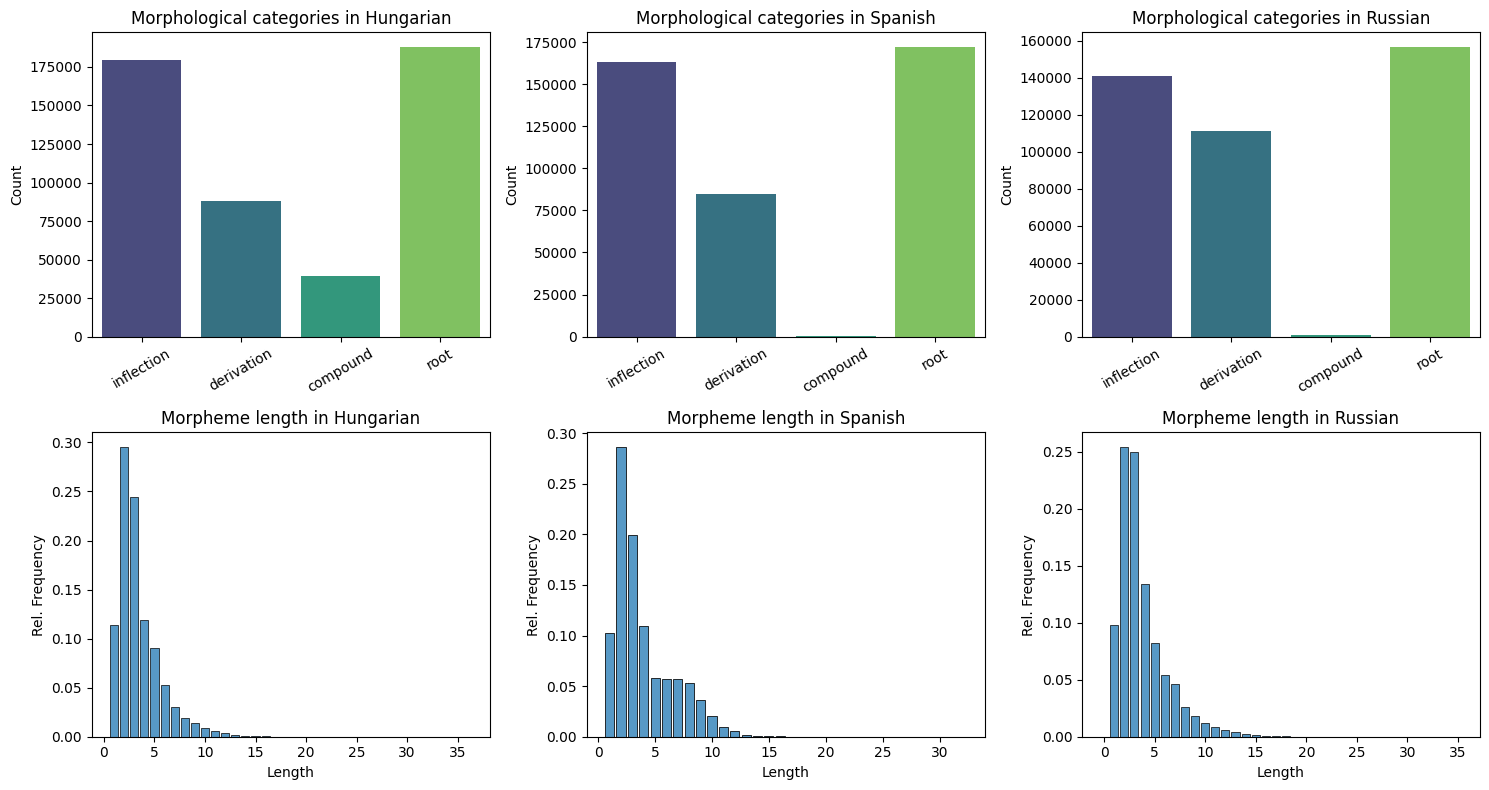

In [31]:
languages = ["hun", "spa", "rus"]
nrows = len(languages)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))


for i, lang in enumerate(languages):
    ax_metrics = axes[0][i]
    lang_metrics = metrics.loc[[lang], ["inflection", "derivation", "compound", "root"]]
    lang_metrics_long = lang_metrics.reset_index().melt(id_vars='lang')
    
    sns.barplot(data=lang_metrics_long, x='variable', y="value", ax=ax_metrics, hue="variable", palette="viridis")
    ax_metrics.set_title(f"Morphological categories in {LANGS[lang]}")
    ax_metrics.set_xlabel("")
    ax_metrics.set_ylabel("Count")
    ax_metrics.tick_params(axis='x', rotation=30)

    ax_dist = axes[1][i]
    lang_dist = exploded[exploded['lang'] == lang]
    
    sns.histplot(data=lang_dist, x='morph_len', stat="probability",
                 discrete=True, ax=ax_dist, shrink=0.8)
    ax_dist.set_title(f"Morpheme length in {LANGS[lang]}")
    ax_dist.set_ylabel("Rel. Frequency")
    ax_dist.set_xlabel("Length")
plt.tight_layout()
plt.show()

### ¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?

Según las gráficas anteriores, podemos ver que en el caso del húngaro, existen mucho más palabas donde ocurre el aglutinamiento de dos o más palabras, tal como se ve reflejado en la categoría "compound".
Además el cociente entre morfemas y palabras es muy alto, lo que sugiere que efectivamente se pueden formar nuevas palabras concatenando otras.

Como contraste podemos ver el español, donde la categoria "compound" casi nunca aparece. Sin embargo, en este caso la razón de morfemas por palabra tambíen es alta, por lo que no podemos considerar que sea un lenguaje aislante. Más bien se considera que el español es una lengua fusiva.

## Extra

In [32]:
import nltk
from nltk.corpus import cess_esp

In [33]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF

In [34]:
nltk.download('cess_esp')

[nltk_data] Downloading package cess_esp to /home/roman/nltk_data...
[nltk_data]   Package cess_esp is already up-to-date!


True

In [35]:
corpora = cess_esp.tagged_sents()

In [36]:
def get_tags_map() -> dict:
    """sauce https://gist.github.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/
    """
    tags_raw = r.get(
        "https://gist.githubusercontent.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/raw/af2d83bc4c2a7e2e6dbb01bd0a10a23a3a21a551/universal_tagset-ES.map"
    ).text.split("\n")
    tags_map = {line.split("\t")[0].lower(): line.split("\t")[1] for line in tags_raw}
    return tags_map


def map_tag(tag: str, tags_map=get_tags_map()) -> str:
    if tags_map.get(tag.lower()) == ".":
        return "PUNCT"
    return tags_map.get(tag.lower(), "N/F")


def parse_tags(corpora: list[list[tuple]]) -> list[list[tuple]]:
    result = []
    for sentence in corpora:
        result.append([(word, map_tag(tag)) for word, tag in sentence])
    return result

In [37]:
parsed_corpora = parse_tags(corpora)

In [ ]:
def word_to_features(sent, i):
    word = sent[i][0]
    features = {
        "word.lower()": word.lower(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
    }
    if i > 0:
        prev_word = sent[i - 1][0]
        features.update(
            {
                "prev_word.lower()": prev_word.lower(),
            }
        )
    else:
        # Beginning of sentence
        features["BOS"] = True
    return features


# Extract features and labels
def sent_to_features(sent) -> list:
    return [word_to_features(sent, i) for i in range(len(sent))]


def sent_to_labels(sent) -> list:
    return [label for token, label in sent]

# Preparando datos para el CRF
X = [sent_to_features(sent) for sent in parsed_corpora]
y = [sent_to_labels(sent) for sent in parsed_corpora]
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026
)
# Initialize and train the CRF tagger: https://sklearn-crfsuite.readthedocs.io/en/latest/api.html
crf = CRF(
    algorithm="lbfgs",
    c2=0.001,
    max_iterations=10,
    verbose=True,
)
try:
    crf.fit(X_train, y_train)
except AttributeError as e:
    print(e)
    
y_pred = crf.predict(X_test)

# Flatten the true and predicted labels
y_test_flat = [label for sent_labels in y_test for label in sent_labels]
y_pred_flat = [label for sent_labels in y_pred for label in sent_labels]

# Evaluate the model
report = classification_report(y_true=y_test_flat, y_pred=y_pred_flat)
rprint(report)

In [39]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Matríz de confusión',
                          cmap=None,
                          normalize=True):
    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    fig = plt.figure(figsize=(13, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha\naccuracy={:0.4f}'.format(accuracy, misclass))
    plt.show()
    return fig

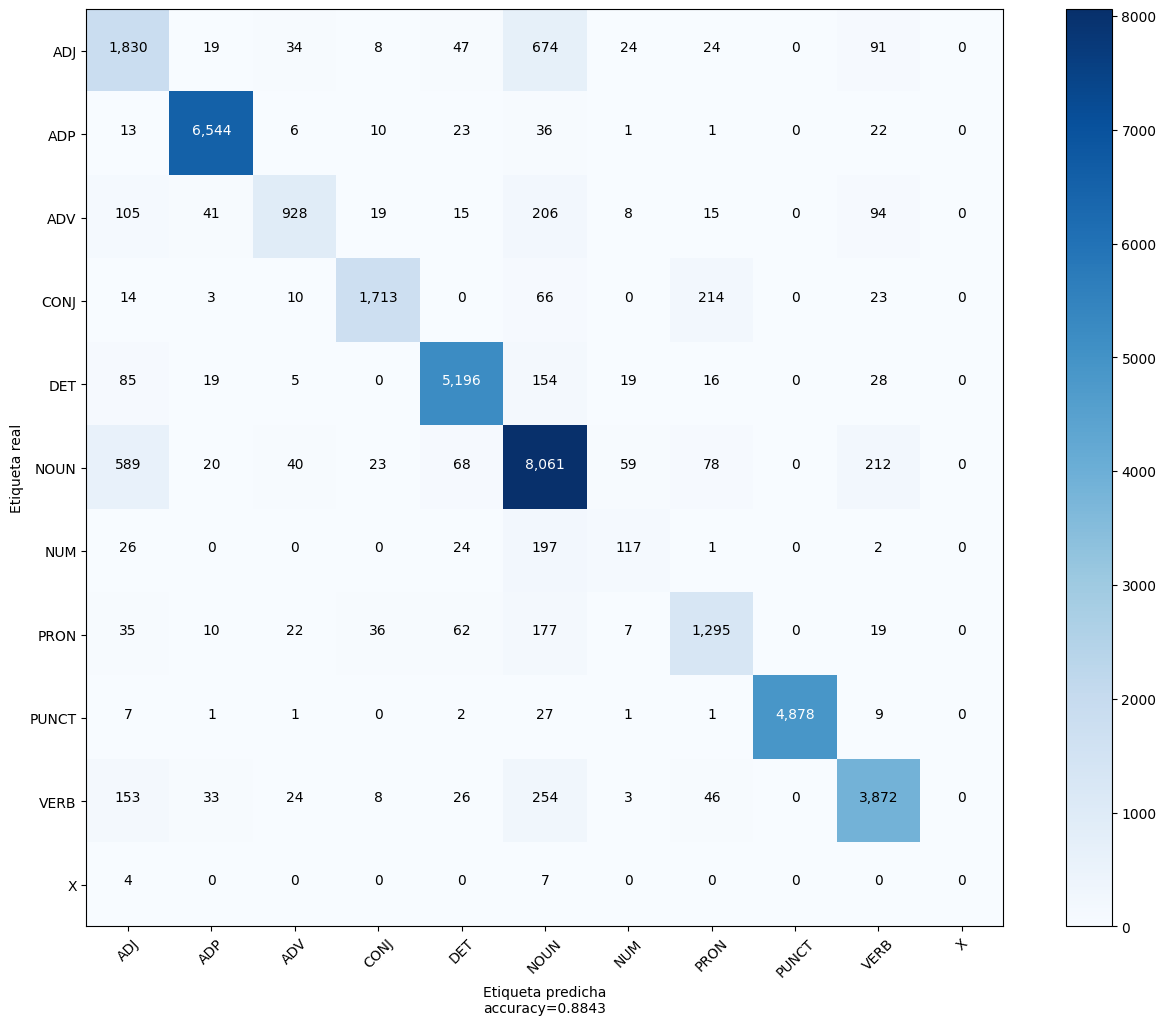

In [40]:
from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

LABELS = ['ADJ',
 'ADP',
 'ADV',
 'CONJ',
 'DET',
 'NOUN',
 'NUM',
 'PRON',
 'PUNCT',
 'VERB',
 'X']

cm =  confusion_matrix(y_test_flat, y_pred_flat, labels=LABELS)

confusion_fig = plot_confusion_matrix(cm = cm,
                                      normalize = False,
                                      target_names=LABELS,
                                      title = "Matríz de confusión")

In [41]:
x_flat = [label for sent_labels in X_test for label in sent_labels]

In [42]:
print(f"|{"Palabra":^20}|{"Real":^10}|{"Predicha":^10}|")
print("-"*43)
for x, yt, yp in zip(x_flat, y_test_flat, y_pred_flat):
    if (yt != yp) & ({yt, yp} == {"ADJ", "NOUN"}):
        print(f"|{x['word.lower()']:^20}|{yt:^10}|{yp:^10}|")

|      Palabra       |   Real   | Predicha |
-------------------------------------------
|       fiscal       |   NOUN   |   ADJ    |
|      navidul       |   NOUN   |   ADJ    |
|        arco        |   NOUN   |   ADJ    |
|     candidatos     |   NOUN   |   ADJ    |
|   contendientes    |   ADJ    |   NOUN   |
|      partidos      |   NOUN   |   ADJ    |
|       número       |   NOUN   |   ADJ    |
|     hipotecas      |   NOUN   |   ADJ    |
|        sola        |   ADJ    |   NOUN   |
|      pequeños      |   ADJ    |   NOUN   |
|      eternos       |   ADJ    |   NOUN   |
|      rivales       |   NOUN   |   ADJ    |
|     escenarios     |   NOUN   |   ADJ    |
|    frigorífico     |   NOUN   |   ADJ    |
|     ejecutivo      |   NOUN   |   ADJ    |
|    aficionados     |   NOUN   |   ADJ    |
|       fuerte       |   ADJ    |   NOUN   |
|       bajada       |   NOUN   |   ADJ    |
|    existencial     |   ADJ    |   NOUN   |
|       mayor        |   ADJ    |   NOUN   |
|        mo

Como podemos ver en la matriz de confusión, los casos donde más se equivoca el modelo es en clasificar sustantivos como adjetivos y vice versa.

Al analizar algunos de estos casos manualmente podemos ver que efectivamente son casos ambiguos.
Por ejemplo:
- "Fiscal": Su etiqueta real es sustantivo como en "el fiscal", pero se predice que sea un adjetivo como en "año fiscal"
- "Pequeños": Su etiqueta real es adjetivo, pero se predice sustantivo.